In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [4]:
google_data = pd.read_csv('googlePlayStore.csv')

In [5]:
google_data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
google_data['Price']

0        0
1        0
2        0
3        0
4        0
        ..
10836    0
10837    0
10838    0
10839    0
10840    0
Name: Price, Length: 10841, dtype: object

In [9]:
google_data['Price'].mean

<bound method Series.mean of 0        0
1        0
2        0
3        0
4        0
        ..
10836    0
10837    0
10838    0
10839    0
10840    0
Name: Price, Length: 10841, dtype: object>

<Axes: >

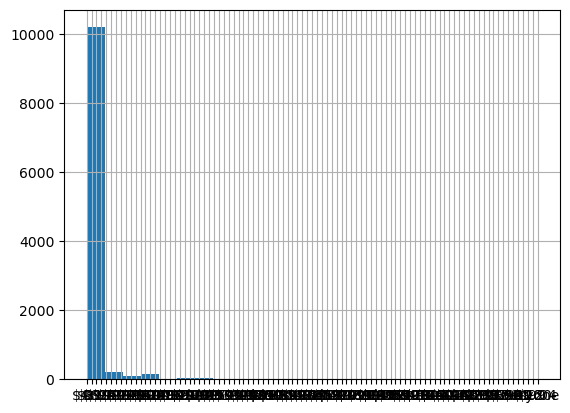

In [19]:
google_data['Price'].hist(bins=25)

In [22]:
# First I'll check the data type
data_types = google_data.dtypes
data_types

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [23]:
# Here I'll check the data for missing values also
missing_values = google_data.isnull().sum()

missing_values

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [25]:
summary_statistics = google_data.describe()

summary_statistics

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [27]:
# Set the aesthetic style of the plot
sns.set_style("whitegrid")

In [28]:
# Plot the distubution of the price column
plt.figure(figsize=(14, 6))


<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

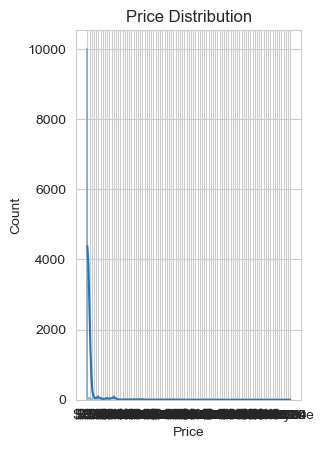

In [30]:
plt.subplot(1, 2, 1)
sns.histplot(google_data['Price'], bins=10, kde=True)
plt.title('Price Distribution')
plt.show()

In [38]:
google_data.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [39]:
google_data['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [41]:
google_data['Price'].value_counts().head(20)

Price
0          10040
$0.99        148
$2.99        129
$1.99         73
$4.99         72
$3.99         63
$1.49         46
$5.99         30
$2.49         26
$9.99         21
$6.99         13
$399.99       12
$14.99        11
$4.49          9
$29.99         7
$24.99         7
$3.49          7
$7.99          7
$5.49          6
$19.99         6
Name: count, dtype: int64

In [42]:
google_data['Price'] = (
    google_data['Price']
    .astype(str)
    .str.replace('$', '', regex=False))


In [43]:
google_data['Price'] = pd.to_numeric(
    google_data['Price'],
    errors='coerce')

In [44]:
google_data['Price'].dtype

dtype('float64')

In [47]:
# In order to the true distrbution data I nedd to remove the paid apps to get a clear 
# picture of the data
paid_apps = google_data[google_data['Price'] > 0]

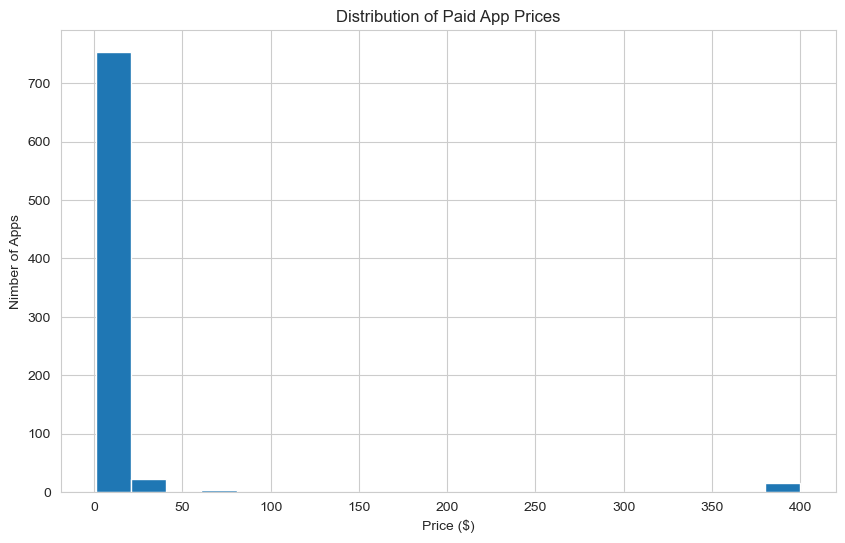

In [49]:
import matplotlib.pyplot as plt

paid_apps['Price'].plot(
    kind= 'hist',
    bins=20,
    figsize=(10, 6))

plt.title('Distribution of Paid App Prices')
plt.xlabel('Price ($)')
plt.ylabel('Nimber of Apps')
plt.show()
           

In [59]:
bins = [-0.01, 0, 1, 5, 10, 20, 50, 100, float('inf')]

labels = [
    'Free',
    '$0-$1',
    '$1-$5',
    '$5-$10',
    '$10-$20',
    '$20-$50',
    '$50-$100',
    '$100+']
    


In [72]:
# when I tried the above code I had some errors (here's the solution below)
google_data['Price'] = (
    google_data['Price']
    .astype(str)
    .str.replace('$', '', regex=False))

In [73]:
google_data['Price'] = pd.to_numeric(
    google_data['Price'],
    errors='coerce')

In [65]:
# checking the data type
google_data['Price'].dtype

dtype('float64')

In [74]:
# Good now we can actually run the code on line 59 
# To show some data on the price of download and get 
# an idea of the price spread.
bins = [-0.01, 0, 1, 5, 10, 20, 50, 100, float('inf')]

labels = [
    'free',
    '$0-$1',
    '$1-$5',
    '$5-$10',
    '$10-$20',
    '$20-$20',
    '$50-$100',
    '$100+']




In [75]:
google_data['Price Range'] = pd.cut(
    google_data['Price'],
    bins=bins,
    labels =labels)
    

In [76]:
google_data['Price Range'].value_counts().sort_index()

Price Range
free        0
$0-$1       0
$1-$5       0
$5-$10      0
$10-$20     0
$20-$20     0
$50-$100    0
$100+       0
Name: count, dtype: int64

In [77]:
google_data['Price'].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Price, dtype: float64